In [28]:
import polars as pl
import matplotlib.pyplot as plt

schema = pl.Schema({"Timers":pl.UInt64(), "TxTime":pl.UInt64(), "RxTime":pl.UInt64()})

raw_c2h_wait={}
raw_h2c_wait={}
raw_c2h_spin={}
raw_h2c_spin={}
raw_c2h_native={}
raw_h2c_native={}

formats=[720, 1080, 2160]
for format in formats:
    raw_c2h_wait[format]=pl.read_csv(f"../data/fabrics-vs-cudamemcpy/test-{format}/MXLFabrics+Cuda2Host+SHM+OneWay+Wait.csv", schema=schema);
    raw_h2c_wait[format]=pl.read_csv(f"../data/fabrics-vs-cudamemcpy/test-{format}/MXLFabrics+Host2Cuda+SHM+OneWay+Wait.csv", schema=schema);
    raw_c2h_spin[format]=pl.read_csv(f"../data/fabrics-vs-cudamemcpy/test-{format}/MXLFabrics+Cuda2Host+SHM+OneWay+Spin.csv", schema=schema);
    raw_h2c_spin[format]=pl.read_csv(f"../data/fabrics-vs-cudamemcpy/test-{format}/MXLFabrics+Host2Cuda+SHM+OneWay+Spin.csv", schema=schema);
    raw_c2h_native[format]=pl.read_csv(f"../data/fabrics-vs-cudamemcpy/test-{format}/NativeCuda+Cuda2Host.csv", schema=schema);
    raw_h2c_native[format]=pl.read_csv(f"../data/fabrics-vs-cudamemcpy/test-{format}/NativeCuda+Host2Cuda.csv", schema=schema);

In [29]:
data_c2h_wait={}
data_h2c_wait={}
data_c2h_spin={}
data_h2c_spin={}
data_c2h_native={}
data_h2c_native={}

for format in formats:
    data_c2h_wait[format] = raw_c2h_wait[format].select(pl.col("RxTime")) - raw_c2h_wait[format].select(pl.col("TxTime"))
    data_c2h_spin[format] = raw_c2h_spin[format].select(pl.col("RxTime")) - raw_c2h_spin[format].select(pl.col("TxTime"))
    data_c2h_native[format] = raw_c2h_native[format].select(pl.col("Timers"))

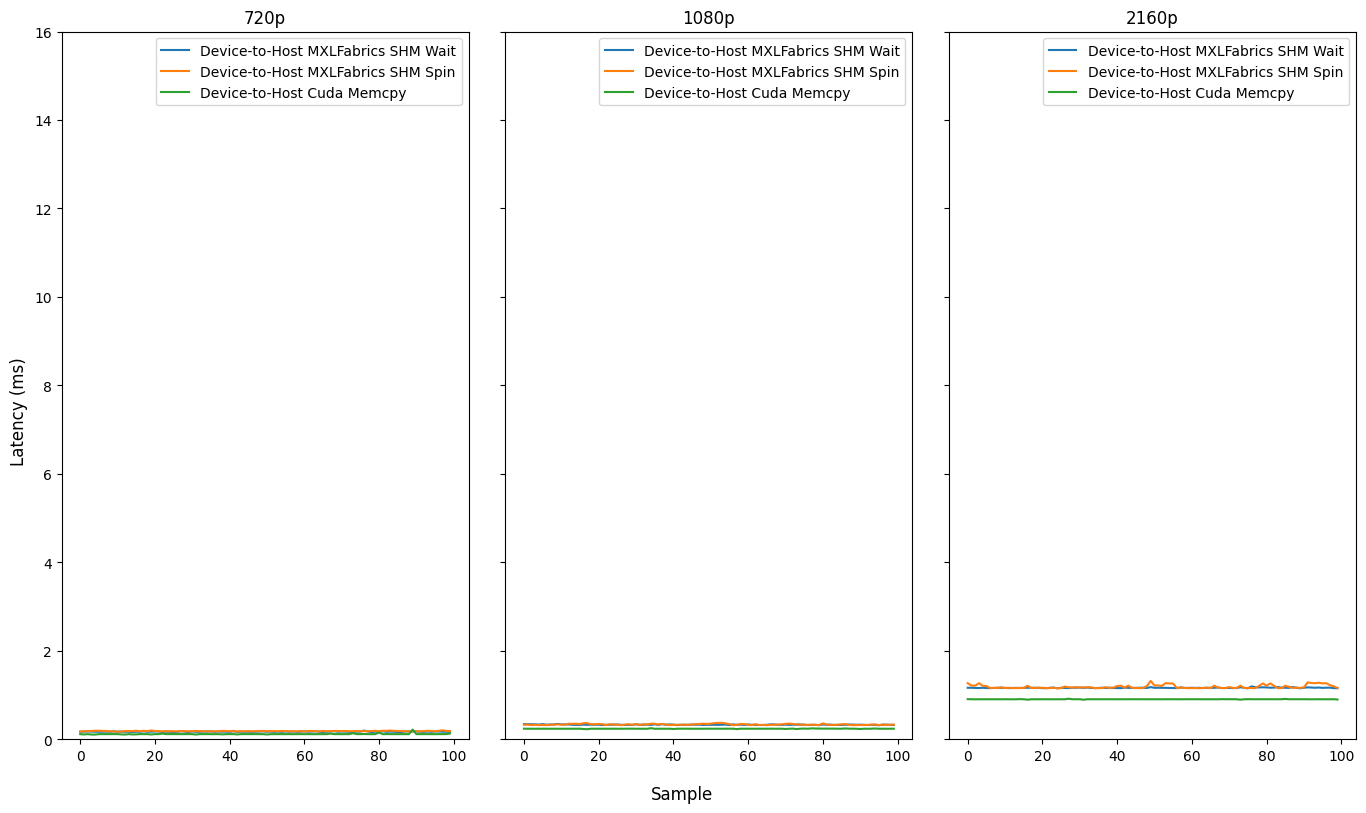

In [30]:
plt.rcParams['figure.figsize'] = [14,8]
fig, axs = plt.subplots(nrows=1,ncols=len(formats), sharex=True, sharey=True)
fig.supylabel("Latency (ms)")
fig.supxlabel("Sample")
fig.tight_layout()

for i, format in enumerate(formats):
    axs[i].set_title(f"{format}p")
    axs[i].set_ylim(0,16)
    axs[i].plot(data_c2h_wait[format]/1e6, label=f"Device-to-Host MXLFabrics SHM Wait")
    axs[i].plot(data_c2h_spin[format]/1e6, label=f"Device-to-Host MXLFabrics SHM Spin")
    axs[i].plot(data_c2h_native[format]/1e6, label=f"Device-to-Host Cuda Memcpy")
    axs[i].legend()
